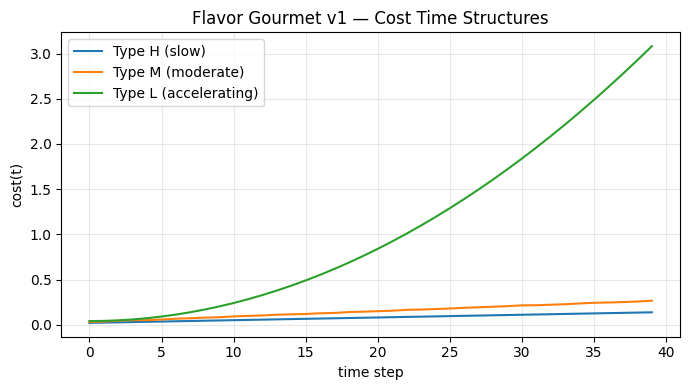

Cell 1 OK — cost generator templates ready.


In [1]:
# ================================================================
# Cell 1 — Flavor Gourmet v1
# Cost Generator: Time-Structured Cost Templates
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Base time axis
# ------------------------------------------------
def make_time_axis(T=40):
    """
    Generate discrete time steps [0, 1, ..., T-1]
    """
    return np.arange(T)


# ------------------------------------------------
# Cost Type H: slow, smooth growth
# (high future tolerance)
# ------------------------------------------------
def cost_type_H(t, base=0.02, slope=0.003):
    """
    Nearly linear, low growth rate.
    Represents inputs that do not immediately threaten system stability.
    """
    return base + slope * t


# ------------------------------------------------
# Cost Type M: moderate, slightly unstable growth
# (homeostatic load)
# ------------------------------------------------
def cost_type_M(t, base=0.03, slope=0.006, noise=0.002):
    """
    Moderate growth with small fluctuations.
    Represents manageable but non-trivial regulation cost.
    """
    rng = np.random.default_rng(42)
    fluct = rng.normal(0, noise, size=len(t))
    return base + slope * t + fluct


# ------------------------------------------------
# Cost Type L: fast, accelerating growth
# (high-risk / damage proxy)
# ------------------------------------------------
def cost_type_L(t, base=0.04, accel=0.002):
    """
    Convex growth (quadratic-like).
    Represents rapidly worsening processing conditions.
    """
    return base + accel * (t ** 2)


# ------------------------------------------------
# Visualization helper (for sanity check)
# ------------------------------------------------
def plot_cost_templates(T=40):
    t = make_time_axis(T)

    c_H = cost_type_H(t)
    c_M = cost_type_M(t)
    c_L = cost_type_L(t)

    plt.figure(figsize=(7, 4))
    plt.plot(t, c_H, label="Type H (slow)")
    plt.plot(t, c_M, label="Type M (moderate)")
    plt.plot(t, c_L, label="Type L (accelerating)")

    plt.xlabel("time step")
    plt.ylabel("cost(t)")
    plt.title("Flavor Gourmet v1 — Cost Time Structures")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# Quick test
# ------------------------------------------------
if __name__ == "__main__":
    plot_cost_templates(T=40)
    print("Cell 1 OK — cost generator templates ready.")

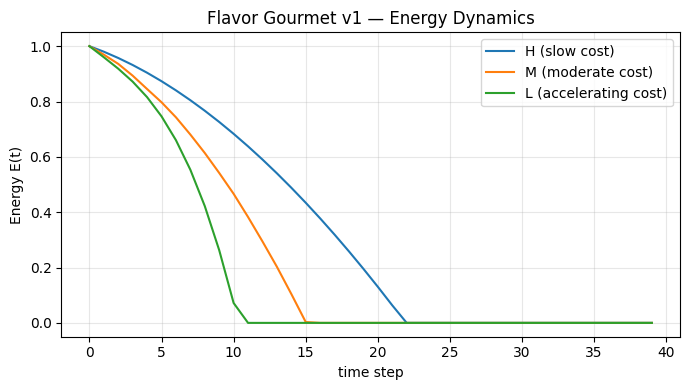

Cell 2 OK — energy dynamics ready.


In [2]:
# ================================================================
# Cell 2 — Flavor Gourmet v1
# Energy State Dynamics
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Energy recovery function (single, blind, global)
# ------------------------------------------------
def recovery(E, r_max=0.015):
    """
    Recovery depends only on current energy.
    Stronger when E is low, vanishes when E is high.
    """
    return r_max * (1.0 - E)


# ------------------------------------------------
# Energy update loop
# ------------------------------------------------
def run_energy_dynamics(cost_t, E0=1.0):
    """
    Given a cost(t) sequence, compute E(t).
    """
    T = len(cost_t)
    E = np.zeros(T)
    E[0] = E0

    for t in range(1, T):
        E[t] = E[t-1] - cost_t[t-1] + recovery(E[t-1])
        E[t] = np.clip(E[t], 0.0, 1.0)

    return E


# ------------------------------------------------
# Visualization helper
# ------------------------------------------------
def plot_energy(cost_dict, T=40, E0=1.0):
    t = np.arange(T)

    plt.figure(figsize=(7, 4))
    for label, cost_t in cost_dict.items():
        E = run_energy_dynamics(cost_t, E0=E0)
        plt.plot(t, E, label=label)

    plt.xlabel("time step")
    plt.ylabel("Energy E(t)")
    plt.title("Flavor Gourmet v1 — Energy Dynamics")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# Quick test using Cell 1 generators
# ------------------------------------------------
if __name__ == "__main__":
    from math import isfinite
    from numpy import arange

    T = 40
    t = arange(T)

    cost_H = cost_type_H(t)
    cost_M = cost_type_M(t)
    cost_L = cost_type_L(t)

    cost_dict = {
        "H (slow cost)": cost_H,
        "M (moderate cost)": cost_M,
        "L (accelerating cost)": cost_L,
    }

    plot_energy(cost_dict, T=T, E0=1.0)
    print("Cell 2 OK — energy dynamics ready.")

Type H (slow): warning at t = None


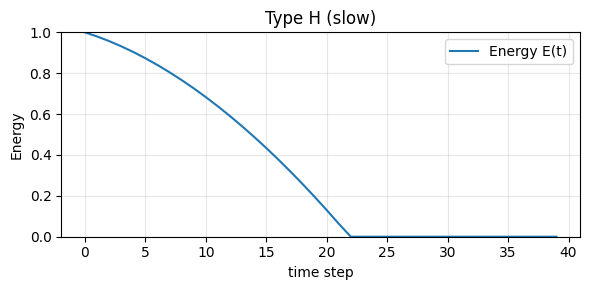

Type M (moderate): warning at t = 13


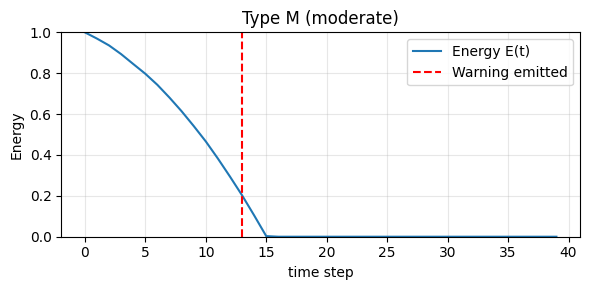

Type L (accelerating): warning at t = 9


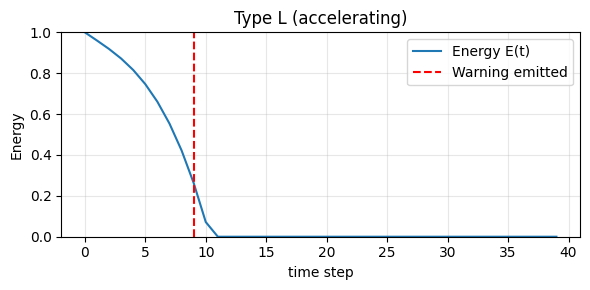

Cell 3 OK — warning gate operational.


In [3]:
# ================================================================
# Cell 3 — Flavor Gourmet v1
# Warning Gate (Interrupt Signal Decision)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Cost trend analysis
# ------------------------------------------------
def cost_trend_features(cost_t):
    """
    Compute first- and second-order differences of cost(t).
    """
    d1 = np.diff(cost_t)          # first derivative
    d2 = np.diff(d1) if len(d1) > 1 else np.array([0.0])  # second derivative
    return d1, d2


# ------------------------------------------------
# Warning gate rule
# ------------------------------------------------
def warning_gate(E_t, cost_t, 
                 E_threshold=0.35,
                 slope_threshold=0.01,
                 accel_threshold=0.002):
    """
    Decide whether to emit a warning signal.
    """
    d1, d2 = cost_trend_features(cost_t)

    # Current trend values (last available)
    slope = d1[-1] if len(d1) > 0 else 0.0
    accel = d2[-1] if len(d2) > 0 else 0.0

    # Gate condition
    if (E_t < E_threshold) and \
       (slope > slope_threshold or accel > accel_threshold):
        return True
    return False


# ------------------------------------------------
# End-to-end test for one cost pattern
# ------------------------------------------------
def run_warning_test(cost_t, E0=1.0):
    """
    Run energy dynamics and determine warning time.
    """
    E = run_energy_dynamics(cost_t, E0=E0)
    T = len(E)
    warning_time = None

    for t in range(5, T):  # allow minimal history
        if warning_gate(E[t], cost_t[:t+1]):
            warning_time = t
            break

    return E, warning_time


# ------------------------------------------------
# Visualization helper
# ------------------------------------------------
def plot_warning(E, warning_time, title=""):
    t = np.arange(len(E))
    plt.figure(figsize=(6, 3))
    plt.plot(t, E, label="Energy E(t)")
    if warning_time is not None:
        plt.axvline(warning_time, color="red", linestyle="--",
                    label="Warning emitted")
    plt.ylim(0, 1)
    plt.xlabel("time step")
    plt.ylabel("Energy")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# Quick test on all cost templates
# ------------------------------------------------
if __name__ == "__main__":
    T = 40
    t = np.arange(T)

    tests = {
        "Type H (slow)": cost_type_H(t),
        "Type M (moderate)": cost_type_M(t),
        "Type L (accelerating)": cost_type_L(t),
    }

    for label, cost_t in tests.items():
        E, w_t = run_warning_test(cost_t)
        print(f"{label}: warning at t = {w_t}")
        plot_warning(E, w_t, title=label)

    print("Cell 3 OK — warning gate operational.")

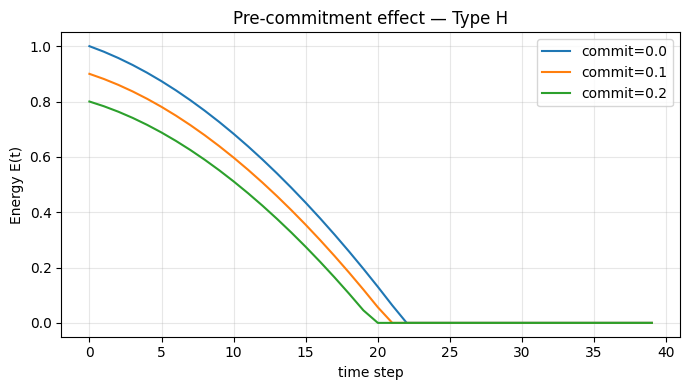

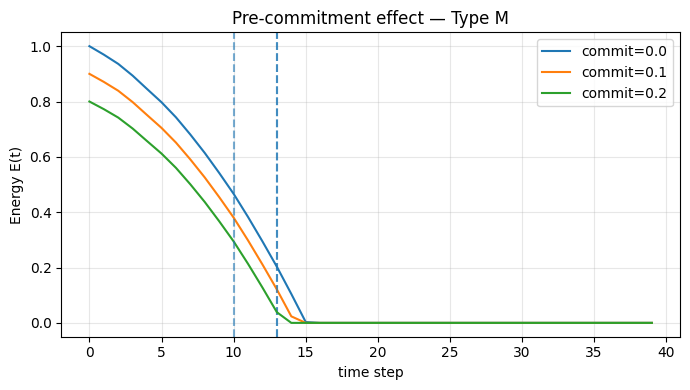

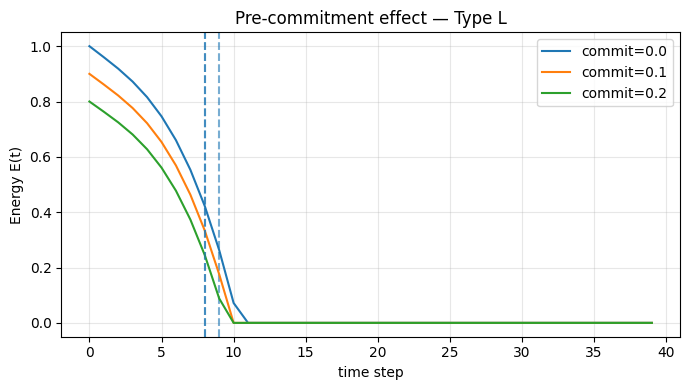

Cell 4 OK — pre-commitment integration complete.


In [4]:
# ================================================================
# Cell 4 — Flavor Gourmet v1
# Pre-commitment (Ingestion) Energy Offset
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Pre-commitment modifier
# ------------------------------------------------
def apply_precommitment(E0, commit_cost=0.15):
    """
    One-time ingestion cost.
    Applied only to initial energy state.
    """
    return max(0.0, E0 - commit_cost)


# ------------------------------------------------
# Run warning test with pre-commitment
# ------------------------------------------------
def run_with_precommitment(cost_t, commit_cost, E0_base=1.0):
    """
    Compare warning timing with and without ingestion cost.
    """
    E0_mod = apply_precommitment(E0_base, commit_cost)
    E, warning_time = run_warning_test(cost_t, E0=E0_mod)
    return E, warning_time


# ------------------------------------------------
# Visualization helper
# ------------------------------------------------
def plot_precommitment_compare(cost_t, label, commit_costs):
    """
    Plot energy trajectories and warning times under
    different pre-commitment costs.
    """
    plt.figure(figsize=(7, 4))

    for c in commit_costs:
        E, w_t = run_with_precommitment(cost_t, c)
        t = np.arange(len(E))
        tag = f"commit={c}"
        plt.plot(t, E, label=tag)
        if w_t is not None:
            plt.axvline(w_t, linestyle="--", alpha=0.6)

    plt.xlabel("time step")
    plt.ylabel("Energy E(t)")
    plt.title(f"Pre-commitment effect — {label}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# Quick test across cost types
# ------------------------------------------------
if __name__ == "__main__":
    T = 40
    t = np.arange(T)

    commit_costs = [0.0, 0.1, 0.2]

    tests = {
        "Type H": cost_type_H(t),
        "Type M": cost_type_M(t),
        "Type L": cost_type_L(t),
    }

    for label, cost_t in tests.items():
        plot_precommitment_compare(cost_t, label, commit_costs)

    print("Cell 4 OK — pre-commitment integration complete.")

In [5]:
# ================================================================
# Cell 5 — Flavor Gourmet v1
# Batch Validation & Falsification
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Batch runner
# ------------------------------------------------
def batch_run(cost_t, commit_costs, E0=1.0):
    """
    For a given cost(t), test warning time under multiple commit costs.
    """
    results = {}
    for c in commit_costs:
        E, w_t = run_with_precommitment(cost_t, c, E0_base=E0)
        results[c] = w_t
    return results


# ------------------------------------------------
# Summary table printer
# ------------------------------------------------
def print_summary(label, results):
    print(f"\n=== {label} ===")
    for c, w in results.items():
        print(f"commit={c:0.2f} -> warning at t = {w}")


# ------------------------------------------------
# Main batch experiment
# ------------------------------------------------
if __name__ == "__main__":
    T = 40
    t = np.arange(T)

    commit_costs = [0.0, 0.05, 0.10, 0.20, 0.30]

    tests = {
        "Type H (slow)": cost_type_H(t),
        "Type M (moderate)": cost_type_M(t),
        "Type L (accelerating)": cost_type_L(t),
    }

    all_results = {}

    for label, cost_t in tests.items():
        res = batch_run(cost_t, commit_costs)
        all_results[label] = res
        print_summary(label, res)

    print("\nCell 5 OK — batch validation completed.")


=== Type H (slow) ===
commit=0.00 -> warning at t = None
commit=0.05 -> warning at t = None
commit=0.10 -> warning at t = None
commit=0.20 -> warning at t = None
commit=0.30 -> warning at t = None

=== Type M (moderate) ===
commit=0.00 -> warning at t = 13
commit=0.05 -> warning at t = 13
commit=0.10 -> warning at t = 13
commit=0.20 -> warning at t = 10
commit=0.30 -> warning at t = 10

=== Type L (accelerating) ===
commit=0.00 -> warning at t = 9
commit=0.05 -> warning at t = 9
commit=0.10 -> warning at t = 8
commit=0.20 -> warning at t = 8
commit=0.30 -> warning at t = 7

Cell 5 OK — batch validation completed.


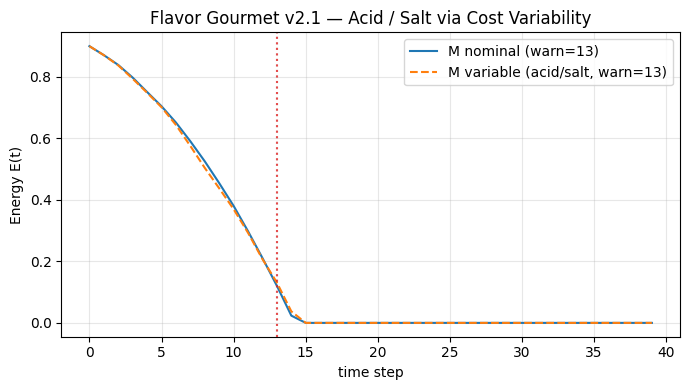

Nominal M warning: 13
Variable M (acid/salt) warning: 13
Cell 6 OK — acid/salt variability probe executed.


In [6]:
# ================================================================
# Cell 6 — Flavor Gourmet v2.1
# Acid / Salt Probe: Cost Variability Modulation
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Variability-augmented M-type cost
# ------------------------------------------------
def cost_type_M_var(t, base=0.03, slope=0.006, noise_scale=0.006, seed=0):
    """
    M-type cost with enhanced temporal variability.
    Mean trend unchanged; variance increased.
    """
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, noise_scale, size=len(t))
    return base + slope * t + noise


# ------------------------------------------------
# Compare nominal M vs variable M (acid/salt probe)
# ------------------------------------------------
def compare_M_variants(T=40, commit_cost=0.1):
    t = np.arange(T)

    cost_M_nominal = cost_type_M(t)
    cost_M_var = cost_type_M_var(t)

    E_nom, w_nom = run_with_precommitment(cost_M_nominal, commit_cost)
    E_var, w_var = run_with_precommitment(cost_M_var, commit_cost)

    # ---- Plot ----
    plt.figure(figsize=(7, 4))
    plt.plot(E_nom, label=f"M nominal (warn={w_nom})")
    plt.plot(E_var, label=f"M variable (acid/salt, warn={w_var})", linestyle="--")

    if w_nom is not None:
        plt.axvline(w_nom, color="gray", linestyle=":", alpha=0.5)
    if w_var is not None:
        plt.axvline(w_var, color="red", linestyle=":", alpha=0.6)

    plt.xlabel("time step")
    plt.ylabel("Energy E(t)")
    plt.title("Flavor Gourmet v2.1 — Acid / Salt via Cost Variability")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "nominal_warning": w_nom,
        "variable_warning": w_var,
        "E_nominal": E_nom,
        "E_variable": E_var
    }


# ------------------------------------------------
# Quick test
# ------------------------------------------------
if __name__ == "__main__":
    result = compare_M_variants(T=40, commit_cost=0.1)
    print("Nominal M warning:", result["nominal_warning"])
    print("Variable M (acid/salt) warning:", result["variable_warning"])
    print("Cell 6 OK — acid/salt variability probe executed.")

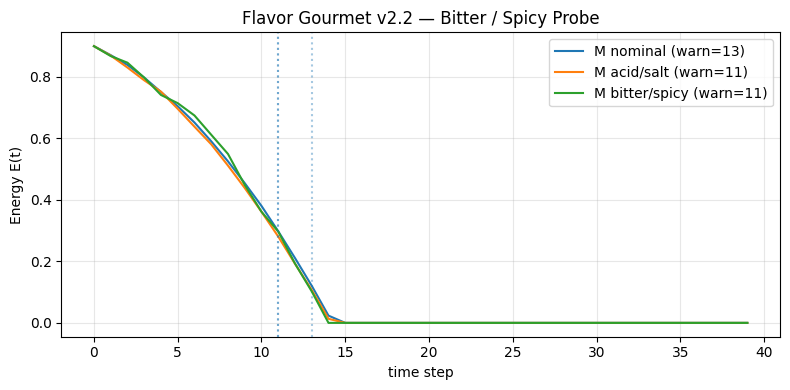

Cell 7 OK — bitter/spicy burst probe executed.


In [7]:
# ================================================================
# Cell 7 — Flavor Gourmet v2.2
# Bitter / Spicy Probe: High-Risk Bursty Variability
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# High-risk bursty M-type cost
# ------------------------------------------------
def cost_type_M_burst(
    t,
    base=0.03,
    slope=0.006,
    noise_scale=0.012,
    burst_scale=0.04,
    burst_start=8,
    burst_duration=4,
    seed=42
):
    """
    M-type cost with strong, short-lived burst of variability.
    Represents bitter/spicy strong stimulus.
    """
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, noise_scale, size=len(t))

    burst = np.zeros_like(t, dtype=float)
    burst_end = min(len(t), burst_start + burst_duration)
    burst[burst_start:burst_end] = rng.normal(
        0, burst_scale, size=(burst_end - burst_start)
    )

    return base + slope * t + noise + burst


# ------------------------------------------------
# Compare nominal M vs acid/salt vs bitter/spicy
# ------------------------------------------------
def compare_M_all_variants(T=40, commit_cost=0.1):
    t = np.arange(T)

    cost_nominal = cost_type_M(t)
    cost_acid = cost_type_M_var(t, noise_scale=0.006, seed=1)
    cost_bitter = cost_type_M_burst(t)

    variants = {
        "M nominal": cost_nominal,
        "M acid/salt": cost_acid,
        "M bitter/spicy": cost_bitter,
    }

    plt.figure(figsize=(8, 4))

    for label, cost_t in variants.items():
        E, w_t = run_with_precommitment(cost_t, commit_cost)
        plt.plot(E, label=f"{label} (warn={w_t})")
        if w_t is not None:
            plt.axvline(w_t, linestyle=":", alpha=0.4)

    plt.xlabel("time step")
    plt.ylabel("Energy E(t)")
    plt.title("Flavor Gourmet v2.2 — Bitter / Spicy Probe")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# Quick test
# ------------------------------------------------
if __name__ == "__main__":
    compare_M_all_variants(T=40, commit_cost=0.1)
    print("Cell 7 OK — bitter/spicy burst probe executed.")

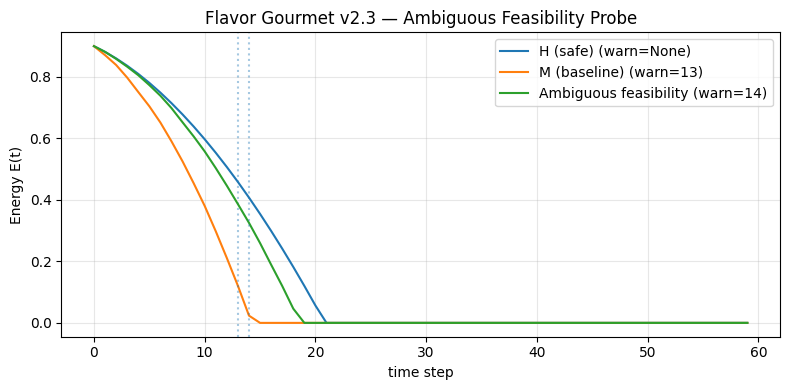

Cell 8 OK — ambiguous feasibility probe executed.


In [8]:
# ================================================================
# Cell 8 — Flavor Gourmet v2.3
# Ambiguous Feasibility Probe (Low-risk, Low-variance Drain)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Ambiguous feasibility cost
# ------------------------------------------------
def cost_type_feas_ambiguous(
    t,
    base=0.02,
    slope=0.004,
    noise_scale=0.002,
    seed=7
):
    """
    Low-risk, low-variance, but slowly draining cost.
    Represents ambiguous feasibility: not bad, not good, just draining.
    """
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, noise_scale, size=len(t))
    return base + slope * t + noise


# ------------------------------------------------
# Compare ambiguous feasibility against baselines
# ------------------------------------------------
def compare_feasibility_variants(T=60, commit_cost=0.1):
    t = np.arange(T)

    cost_H = cost_type_H(t)
    cost_M = cost_type_M(t)
    cost_amb = cost_type_feas_ambiguous(t)

    variants = {
        "H (safe)": cost_H,
        "M (baseline)": cost_M,
        "Ambiguous feasibility": cost_amb,
    }

    plt.figure(figsize=(8, 4))

    for label, cost_t in variants.items():
        E, w_t = run_with_precommitment(cost_t, commit_cost)
        plt.plot(E, label=f"{label} (warn={w_t})")
        if w_t is not None:
            plt.axvline(w_t, linestyle=":", alpha=0.4)

    plt.xlabel("time step")
    plt.ylabel("Energy E(t)")
    plt.title("Flavor Gourmet v2.3 — Ambiguous Feasibility Probe")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return variants


# ------------------------------------------------
# Quick test
# ------------------------------------------------
if __name__ == "__main__":
    compare_feasibility_variants(T=60, commit_cost=0.1)
    print("Cell 8 OK — ambiguous feasibility probe executed.")

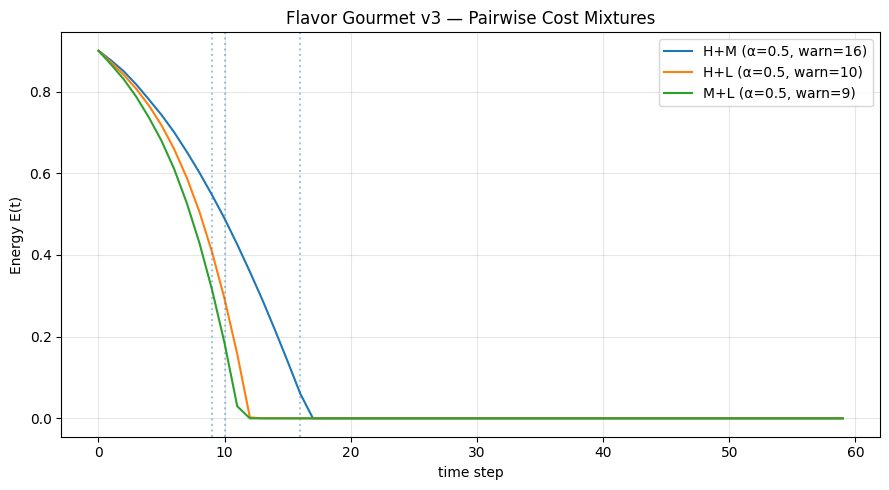

Cell 9 OK — pairwise mixtures executed.


In [9]:
# ================================================================
# Cell 9 — Flavor Gourmet v3
# Pairwise Cost Mixtures (H+M, H+L, M+L)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Linear cost mixture
# ------------------------------------------------
def mix_cost(cost_A, cost_B, alpha=0.5):
    """
    Linear mixture of two cost time series.
    """
    return alpha * cost_A + (1 - alpha) * cost_B


# ------------------------------------------------
# Run and plot a single mixture
# ------------------------------------------------
def run_mix(cost_A, cost_B, label_A, label_B, alpha=0.5,
            T=60, commit_cost=0.1):
    t = np.arange(T)
    cost_mix = mix_cost(cost_A, cost_B, alpha)

    E, w_t = run_with_precommitment(cost_mix, commit_cost)

    plt.plot(E, label=f"{label_A}+{label_B} (α={alpha}, warn={w_t})")
    if w_t is not None:
        plt.axvline(w_t, linestyle=":", alpha=0.4)

    return w_t


# ------------------------------------------------
# Pairwise mixture experiment
# ------------------------------------------------
def run_pairwise_mixtures(T=60, commit_cost=0.1, alpha=0.5):
    t = np.arange(T)

    cost_H = cost_type_H(t)
    cost_M = cost_type_M(t)
    cost_L = cost_type_L(t)

    pairs = [
        (cost_H, cost_M, "H", "M"),
        (cost_H, cost_L, "H", "L"),
        (cost_M, cost_L, "M", "L"),
    ]

    plt.figure(figsize=(9, 5))

    for cost_A, cost_B, lab_A, lab_B in pairs:
        run_mix(cost_A, cost_B, lab_A, lab_B,
                alpha=alpha, T=T, commit_cost=commit_cost)

    plt.xlabel("time step")
    plt.ylabel("Energy E(t)")
    plt.title("Flavor Gourmet v3 — Pairwise Cost Mixtures")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# Quick test
# ------------------------------------------------
if __name__ == "__main__":
    run_pairwise_mixtures(
        T=60,
        commit_cost=0.1,
        alpha=0.5
    )
    print("Cell 9 OK — pairwise mixtures executed.")

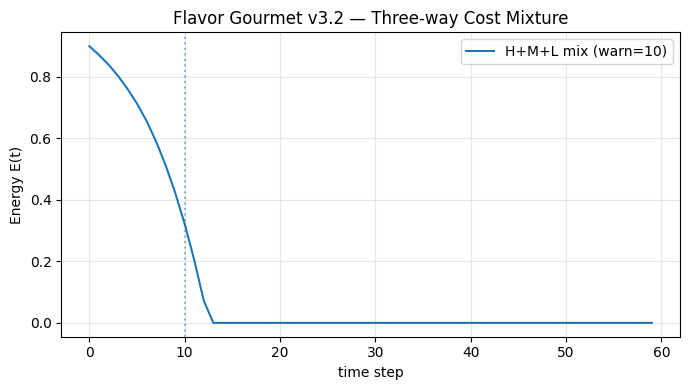

Three-way mixture warning time: 10
Cell 10 OK — three-way mixture executed.


In [10]:
# ================================================================
# Cell 10 — Flavor Gourmet v3.2
# Three-way Cost Mixture (H + M + L)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Three-way linear cost mixture
# ------------------------------------------------
def mix_cost_three(cost_H, cost_M, cost_L,
                   wH=1/3, wM=1/3, wL=1/3):
    """
    Linear mixture of H, M, L costs.
    Weights must sum to 1.
    """
    return wH * cost_H + wM * cost_M + wL * cost_L


# ------------------------------------------------
# Run and plot three-way mixture
# ------------------------------------------------
def run_three_way_mixture(T=60, commit_cost=0.1,
                          wH=1/3, wM=1/3, wL=1/3):
    t = np.arange(T)

    cost_H = cost_type_H(t)
    cost_M = cost_type_M(t)
    cost_L = cost_type_L(t)

    cost_mix = mix_cost_three(cost_H, cost_M, cost_L,
                              wH=wH, wM=wM, wL=wL)

    E, w_t = run_with_precommitment(cost_mix, commit_cost)

    plt.figure(figsize=(7, 4))
    plt.plot(E, label=f"H+M+L mix (warn={w_t})")
    if w_t is not None:
        plt.axvline(w_t, linestyle=":", alpha=0.5)

    plt.xlabel("time step")
    plt.ylabel("Energy E(t)")
    plt.title("Flavor Gourmet v3.2 — Three-way Cost Mixture")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return E, w_t


# ------------------------------------------------
# Quick test
# ------------------------------------------------
if __name__ == "__main__":
    E, w_t = run_three_way_mixture(
        T=60,
        commit_cost=0.1,
        wH=1/3, wM=1/3, wL=1/3
    )
    print("Three-way mixture warning time:", w_t)
    print("Cell 10 OK — three-way mixture executed.")